# Notebook: Modeling Heart Attack Prediction

Deskripsi: Notebook ini melakukan proses modelling untuk prediksi risiko serangan jantung menggunakan Logistic Regression, Random Forest, SVM, KNN, dan XGBoost. Langkah meliputi: EDA, preprocessing, training, hyperparameter tuning, evaluasi, dan penyimpanan model.

Random seed: 42

In [22]:
# Install (optional) and import libraries
!pip install -q xgboost shap joblib imbalanced-learn

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix, roc_curve, auc)

import xgboost as xgb
import joblib
import shap
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
print('numpy:', np.__version__, 'pandas:', pd.__version__, 'xgboost:', xgb.__version__)


numpy: 2.1.3 pandas: 2.2.3 xgboost: 3.1.3



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# Load dataset
DATA_PATH = r'd:\bootcamp DS\heart_attack_prediction_dataset.csv'
df = pd.read_csv(DATA_PATH)

print('Shape:', df.shape)
df.head()


Shape: (8763, 26)


,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   object 
 3   Cholesterol                      8763 non-null   int64  
 4   Blood Pressure                   8763 non-null   object 
 5   Heart Rate                       8763 non-null   int64  
 6   Diabetes                         8763 non-null   int64  
 7   Family History                   8763 non-null   int64  
 8   Smoking                          8763 non-null   int64  
 9   Obesity                          8763 non-null   int64  
 10  Alcohol Consumption              8763 non-null   int64  
 11  Exercise Hours Per Week          8763 non-null   float64
 12  Diet                

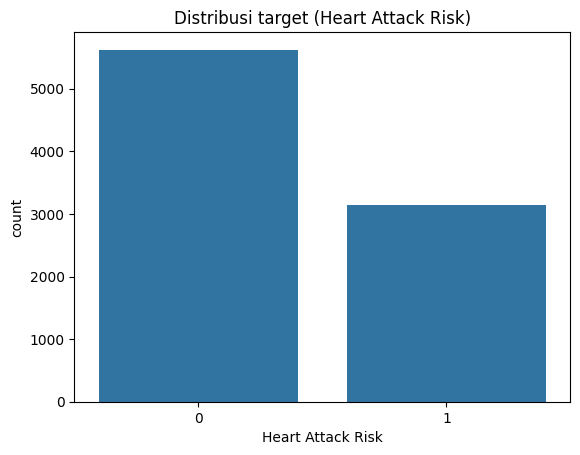

In [6]:
# Quick EDA: dtypes, missing values, target distribution
print(df.info())
print('\nMissing values per column:\n', df.isnull().sum())

print('\nTarget distribution:')
print(df['Heart Attack Risk'].value_counts(normalize=True))

sns.countplot(x='Heart Attack Risk', data=df)
plt.title('Distribusi target (Heart Attack Risk)')
plt.show()

In [11]:
# Preprocessing & feature engineering
# Drop Patient ID (identifier)
df = df.copy()
if 'Patient ID' in df.columns:
    df = df.drop(columns=['Patient ID'])

# Parse Blood Pressure into Systolic and Diastolic
if 'Blood Pressure' in df.columns:
    bp = df['Blood Pressure'].astype(str).str.split('/', expand=True)
    df['Systolic'] = pd.to_numeric(bp[0], errors='coerce')
    df['Diastolic'] = pd.to_numeric(bp[1], errors='coerce')
    df = df.drop(columns=['Blood Pressure'])

# Map Sex
if 'Sex' in df.columns:
    df['Sex'] = df['Sex'].map({'Male':1, 'Female':0})

# Map Diet ordinal (Healthy=0, Average=1, Unhealthy=2) if exists
if 'Diet' in df.columns:
    df['Diet'] = df['Diet'].map({'Healthy':0, 'Average':1, 'Unhealthy':2})

# Drop high-cardinality 'Country' to keep model simple
if 'Country' in df.columns:
    df = df.drop(columns=['Country'])

# Check resulting columns
print('Columns after preprocessing:', df.columns.tolist())
df.head()

Columns after preprocessing: ['Age', 'Sex', 'Cholesterol', 'Heart Rate', 'Diabetes', 'Family History', 'Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week', 'Diet', 'Previous Heart Problems', 'Medication Use', 'Stress Level', 'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides', 'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Continent', 'Hemisphere', 'Heart Attack Risk', 'Systolic', 'Diastolic']


,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,...,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Continent,Hemisphere,Heart Attack Risk,Systolic,Diastolic
0,67,NaN,208,72,0,0,1,0,0,4.168189,...,261404,31.251233,286,0,6,South America,Southern Hemisphere,0,158,88
1,21,NaN,389,98,1,1,1,1,1,1.813242,...,285768,27.194973,235,1,7,North America,Northern Hemisphere,0,165,93
2,21,NaN,324,72,1,0,0,0,0,2.078353,...,235282,28.176571,587,4,4,Europe,Northern Hemisphere,0,174,99
3,84,NaN,383,73,1,1,1,0,1,9.828130,...,125640,36.464704,378,3,4,North America,Northern Hemisphere,0,163,100
4,66,NaN,318,93,1,1,1,1,0,5.804299,...,160555,21.809144,231,1,5,Asia,Northern Hemisphere,0,91,88


In [28]:
# Feature / target split
TARGET = 'Heart Attack Risk'
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Train-test split with stratify
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
print('Class distribution in training set:\n', y_train.value_counts())

# Calculate scale_pos_weight for class weighting in XGBoost
count_neg = (y_train == 0).sum()
count_pos = (y_train == 1).sum()
SCALE_POS_WEIGHT = count_neg / count_pos
print(f'\nSCALE_POS_WEIGHT for XGBoost: {SCALE_POS_WEIGHT:.4f}')


Train shape: (7010, 24) Test shape: (1753, 24)
Class distribution in training set:
 Heart Attack Risk
0    4499
1    2511
Name: count, dtype: int64

SCALE_POS_WEIGHT for XGBoost: 1.7917


In [14]:
# Prepare preprocessing pipelines
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
# Remove target if accidentally included
numeric_cols = [c for c in numeric_cols if c != TARGET]
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print('Numeric cols:', numeric_cols)
print('Categorical cols:', categorical_cols)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])


Numeric cols: ['Age', 'Sex', 'Cholesterol', 'Heart Rate', 'Diabetes', 'Family History', 'Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week', 'Diet', 'Previous Heart Problems', 'Medication Use', 'Stress Level', 'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides', 'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Systolic', 'Diastolic']
Categorical cols: ['Continent', 'Hemisphere']


In [ ]:
# Helper to run GridSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

from time import time

def run_grid(name, estimator, param_grid):
    # Use imblearn Pipeline to apply preprocessing -> SMOTE -> classifier
    pipe = ImbPipeline(steps=[('preprocess', preprocessor), ('smote', SMOTE(random_state=RANDOM_STATE)), ('clf', estimator)])
    grid = GridSearchCV(pipe, param_grid=param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1)
    t0 = time()
    grid.fit(X_train, y_train)
    t1 = time()
    print(f"{name} best roc_auc: {grid.best_score_:.4f} (time: {t1-t0:.1f}s)")
    print('Best params:', grid.best_params_)
    return grid


In [29]:
# Define models and parameter grids
models_grids = {}

# Logistic Regression
models_grids['LogisticRegression'] = (
    LogisticRegression(random_state=RANDOM_STATE, solver='liblinear', max_iter=1000),
    {
        'clf__C': [0.01, 0.1, 1, 10],
        'clf__penalty': ['l1', 'l2'],
        'clf__class_weight': [None, 'balanced']
    }
)

# Random Forest
models_grids['RandomForest'] = (
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    {
        'clf__n_estimators': [100, 300],
        'clf__max_features': ['sqrt', 'log2'],
        'clf__class_weight': [None, 'balanced']
    }
)

# SVM
models_grids['SVM'] = (
    SVC(probability=True, random_state=RANDOM_STATE),
    {
        'clf__C': [0.1, 1, 10],
        'clf__kernel': ['rbf', 'linear'],
        'clf__gamma': ['scale', 'auto']
    }
)

# KNN
models_grids['KNN'] = (
    KNeighborsClassifier(),
    {
        'clf__n_neighbors': [3, 5, 7],
        'clf__weights': ['uniform', 'distance']
    }
)

# XGBoost
models_grids['XGBoost'] = (
    xgb.XGBClassifier(random_state=RANDOM_STATE, use_label_encoder=False, eval_metric='logloss', n_jobs=-1),
    {
        'clf__n_estimators': [100, 200],
        'clf__max_depth': [3, 6],
        'clf__learning_rate': [0.01, 0.1],
        'clf__subsample': [0.8, 1.0],
        'clf__scale_pos_weight': [1.0, SCALE_POS_WEIGHT]
    }
)

# AdaBoost
models_grids['AdaBoost'] = (
    AdaBoostClassifier(random_state=RANDOM_STATE),
    {
        'clf__n_estimators': [50, 100, 200],
        'clf__learning_rate': [0.5, 1.0]
    }
)

# Gradient Boosting (sklearn)
models_grids['GradientBoosting'] = (
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    {
        'clf__n_estimators': [100, 200],
        'clf__max_depth': [3, 5],
        'clf__min_weight_fraction_leaf': [0.0, 0.1]
    }
)

# Run grid searches (this will take some time)
grids = {}
for name, (est, grid) in models_grids.items():
    print('\nRunning:', name)
    grids[name] = run_grid(name, est, grid)






Running: LogisticRegression
Fitting 5 folds for each of 16 candidates, totalling 80 fits
LogisticRegression best roc_auc: 0.5099 (time: 7.1s)
Best params: {'clf__C': 0.01, 'clf__class_weight': None, 'clf__penalty': 'l2'}

Running: RandomForest
Fitting 5 folds for each of 8 candidates, totalling 40 fits
RandomForest best roc_auc: 0.4978 (time: 14.1s)
Best params: {'clf__class_weight': 'balanced', 'clf__max_features': 'sqrt', 'clf__n_estimators': 100}

Running: SVM
Fitting 5 folds for each of 12 candidates, totalling 60 fits
SVM best roc_auc: 0.5081 (time: 145.4s)
Best params: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}

Running: KNN
Fitting 5 folds for each of 6 candidates, totalling 30 fits
KNN best roc_auc: 0.4882 (time: 0.6s)
Best params: {'clf__n_neighbors': 3, 'clf__weights': 'uniform'}

Running: XGBoost
Fitting 5 folds for each of 32 candidates, totalling 160 fits
XGBoost best roc_auc: 0.5118 (time: 7.3s)
Best params: {'clf__learning_rate': 0.1, 'clf__max_depth

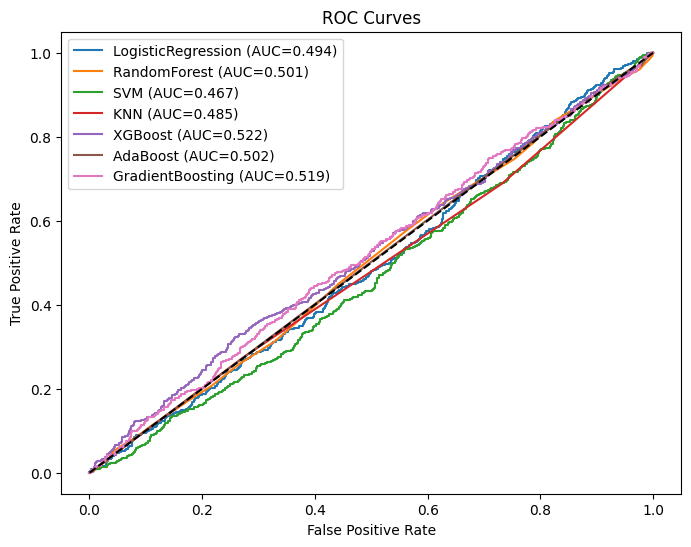

,model,accuracy,precision,recall,f1,roc_auc
4,XGBoost,0.642898,0.533333,0.025478,0.048632,0.521573
6,GradientBoosting,0.634912,0.333333,0.019108,0.036145,0.519066
5,AdaBoost,0.641757,0.000000,0.000000,0.000000,0.501752
1,RandomForest,0.637764,0.294118,0.007962,0.015504,0.500680
0,LogisticRegression,0.641757,0.000000,0.000000,0.000000,0.494301
3,KNN,0.564746,0.359667,0.275478,0.311993,0.484697
2,SVM,0.641757,0.000000,0.000000,0.000000,0.467155


In [30]:
# Evaluate models on test set
results = []
plt.figure(figsize=(8,6))

for name, grid in grids.items():
    best = grid.best_estimator_
    y_pred = best.predict(X_test)
    # Get probability or scores
    if hasattr(best, 'predict_proba'):
        y_score = best.predict_proba(X_test)[:,1]
    else:
        try:
            y_score = best.decision_function(X_test)
        except Exception:
            y_score = best.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_score)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc:.3f})")

    results.append({'model': name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'roc_auc': roc})

plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

results_df = pd.DataFrame(results).sort_values('roc_auc', ascending=False)
results_df

Best model (by ROC AUC): XGBoost

Classification report:
              precision    recall  f1-score   support

           0       0.64      0.99      0.78      1125
           1       0.53      0.03      0.05       628

    accuracy                           0.64      1753
   macro avg       0.59      0.51      0.41      1753
weighted avg       0.60      0.64      0.52      1753



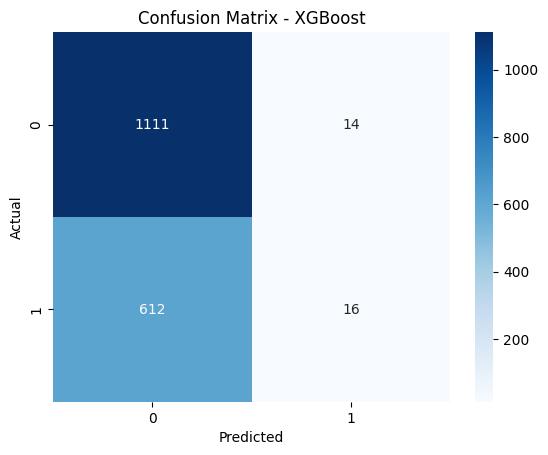

In [31]:
# Confusion matrix & classification report for best model
best_name = results_df.iloc[0]['model']
best_grid = grids[best_name]
best_model = best_grid.best_estimator_
print('Best model (by ROC AUC):', best_name)

y_pred_best = best_model.predict(X_test)
print('\nClassification report:')
print(classification_report(y_test, y_pred_best, zero_division=0))

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_name}')
plt.show()


In [ ]:
# Feature importance: RandomForest and XGBoost (if available)
from sklearn.exceptions import NotFittedError

def get_feature_names(preprocessor):
    try:
        return preprocessor.get_feature_names_out()
    except Exception:
        # Fallback: construct names manually
        num = numeric_cols
        cat = []
        if categorical_cols:
            ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
            cat_names = list(ohe.get_feature_names_out(categorical_cols))
            return np.array(num + cat_names)
        return np.array(num)

# Random Forest
if 'RandomForest' in grids:
    rf = grids['RandomForest'].best_estimator_
    try:
        feat_names = get_feature_names(rf.named_steps['preprocess'])
        importances = rf.named_steps['clf'].feature_importances_
        fi = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(20)
        plt.figure(figsize=(8,6))
        fi.plot(kind='barh')
        plt.gca().invert_yaxis()
        plt.title('Top 20 Feature Importances - RandomForest')
        plt.show()
    except Exception as e:
        print('Could not compute RF feature importances:', e)

# XGBoost
if 'XGBoost' in grids:
    xgbm = grids['XGBoost'].best_estimator_
    try:
        feat_names = get_feature_names(xgbm.named_steps['preprocess'])
        importances = xgbm.named_steps['clf'].feature_importances_
        fi = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(20)
        plt.figure(figsize=(8,6))
        fi.plot(kind='barh')
        plt.gca().invert_yaxis()
        plt.title('Top 20 Feature Importances - XGBoost')
        plt.show()
    except Exception as e:
        print('Could not compute XGBoost feature importances:', e)


In [ ]:
# Save best model
best_overall_name = results_df.iloc[0]['model']
best_overall = grids[best_overall_name].best_estimator_
joblib.dump(best_overall, r'd:\bootcamp DS\best_model_heart_attack.joblib')
print('Saved best model:', best_overall_name)

# Save comparison results
results_df.to_csv(r'd:\bootcamp DS\model_comparison.csv', index=False)
print('Saved model comparison to model_comparison.csv')

# Example inference using the saved model
sample = X_test.iloc[:3]
loaded = joblib.load(r'd:\bootcamp DS\best_model_heart_attack.joblib')
print('Sample predictions (label):', loaded.predict(sample))
print('Sample probabilities:', loaded.predict_proba(sample)[:,1])


## Kesimpulan & langkah selanjutnya

- Notebook ini melakukan preprocessing, training, hyperparameter tuning, dan evaluasi untuk Logistic Regression, Random Forest, SVM, KNN, dan XGBoost.
- Model terbaik disimpan sebagai `best_model_heart_attack.joblib` dan hasil perbandingan disimpan di `model_comparison.csv`.

Reproducibility 🔁:
- Semua estimator menggunakan `random_state=42`.
- Untuk reproduksi lingkungan, jalankan `pip freeze > requirements.txt` di environment Anda.

Langkah selanjutnya:
- Melakukan tuning yang lebih mendalam (RandomizedSearch / Bayesian), menambahkan SHAP untuk interpretabilitas, dan eksperimen feature engineering baru.

✅ Jika Anda ingin, saya bisa menjalankan notebook ini dan mengirimkan ringkasan hasil (mis. model terbaik, metrik, dan plot).